# SESSION 04: HISTOGRAM AND HISTOGRAM EQUALIZATION

- Ex4_1: Histogram Representation
- Ex4_2: Histogram Equalization
- Ex4_3: Contrast Limited Adaptive Histogram Equalization (clahe)
- Ex4_4: Local Histogram Equalization

In [3]:
# Load packages
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [4]:
# connect to GG Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
# Create a path link to Session folder
PATH = '/content/drive/MyDrive/IVP/Session_04/'

# Font size for figures
FS = 12

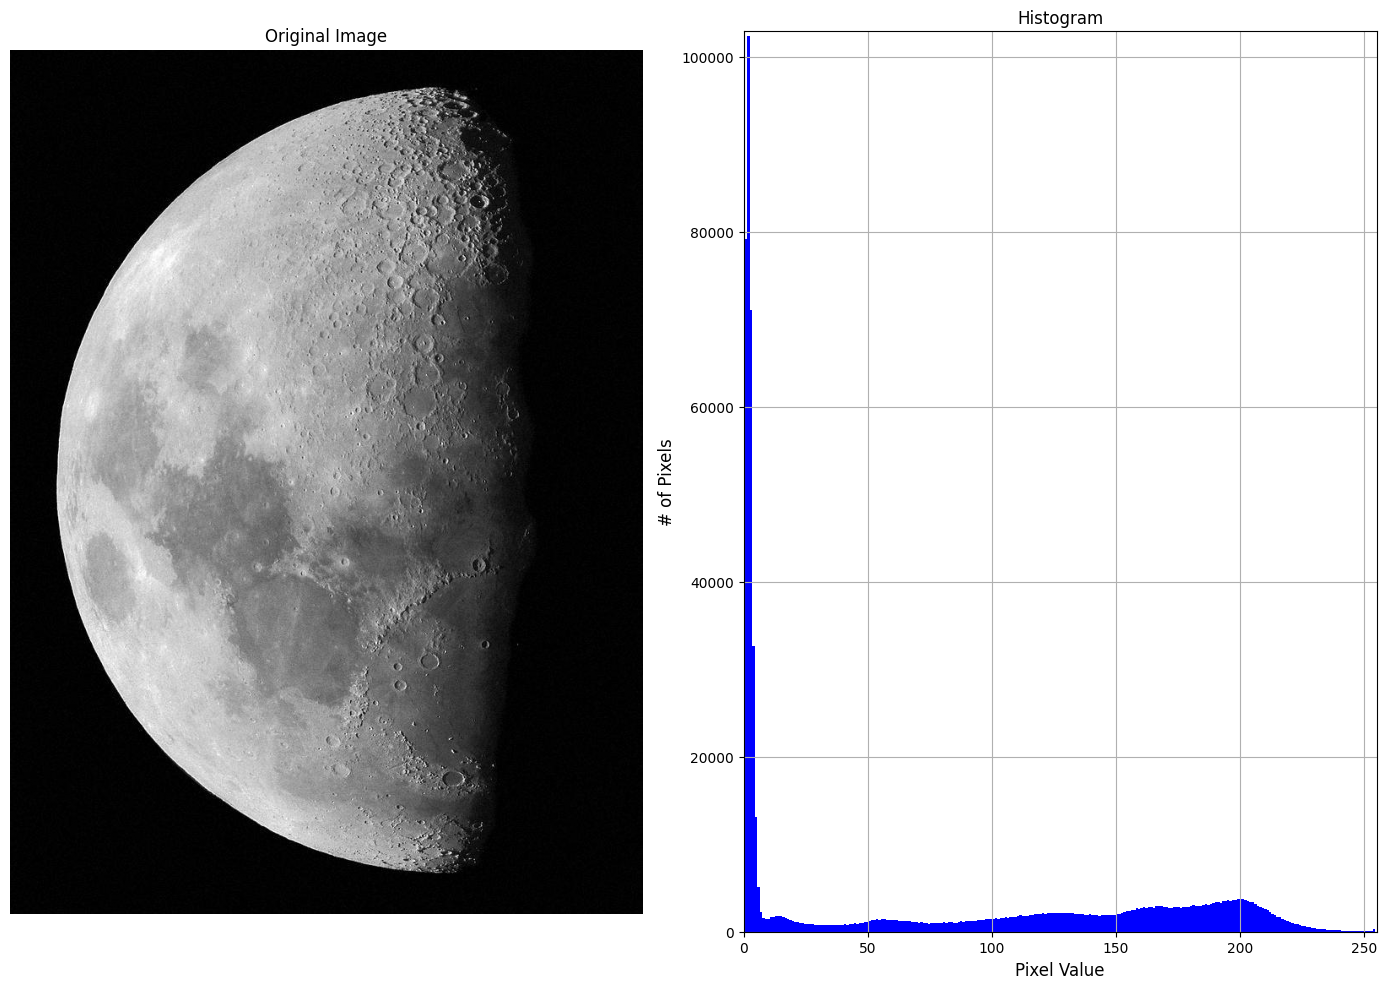

In [6]:
# Ex4_1: Histogram Representation
Img = cv2.imread(PATH + 'moon.jpg', cv2.IMREAD_GRAYSCALE)

# Calculate image histogram
count, bins = np.histogram(Img.flatten(), bins=256, range=(0, 255))

# Display_results
plt.figure(figsize=(14, 10))

plt.subplot(1, 2, 1), plt.imshow(Img, cmap='gray')
plt.title('Original Image', fontsize=FS)
plt.axis('off')

plt.subplot(1, 2, 2), plt.bar(bins[:-1], count, width=1.0, color='blue')
plt.xlim([0, 255]), plt.ylim([0, count.max()+500]), plt.grid(True)
plt.title('Histogram', fontsize=FS)
plt.xlabel('Pixel Value', fontsize=FS)
plt.ylabel('# of Pixels', fontsize=FS)

plt.tight_layout()
plt.savefig(PATH + 'Ex4_1.jpg', dpi=400)
plt.show()


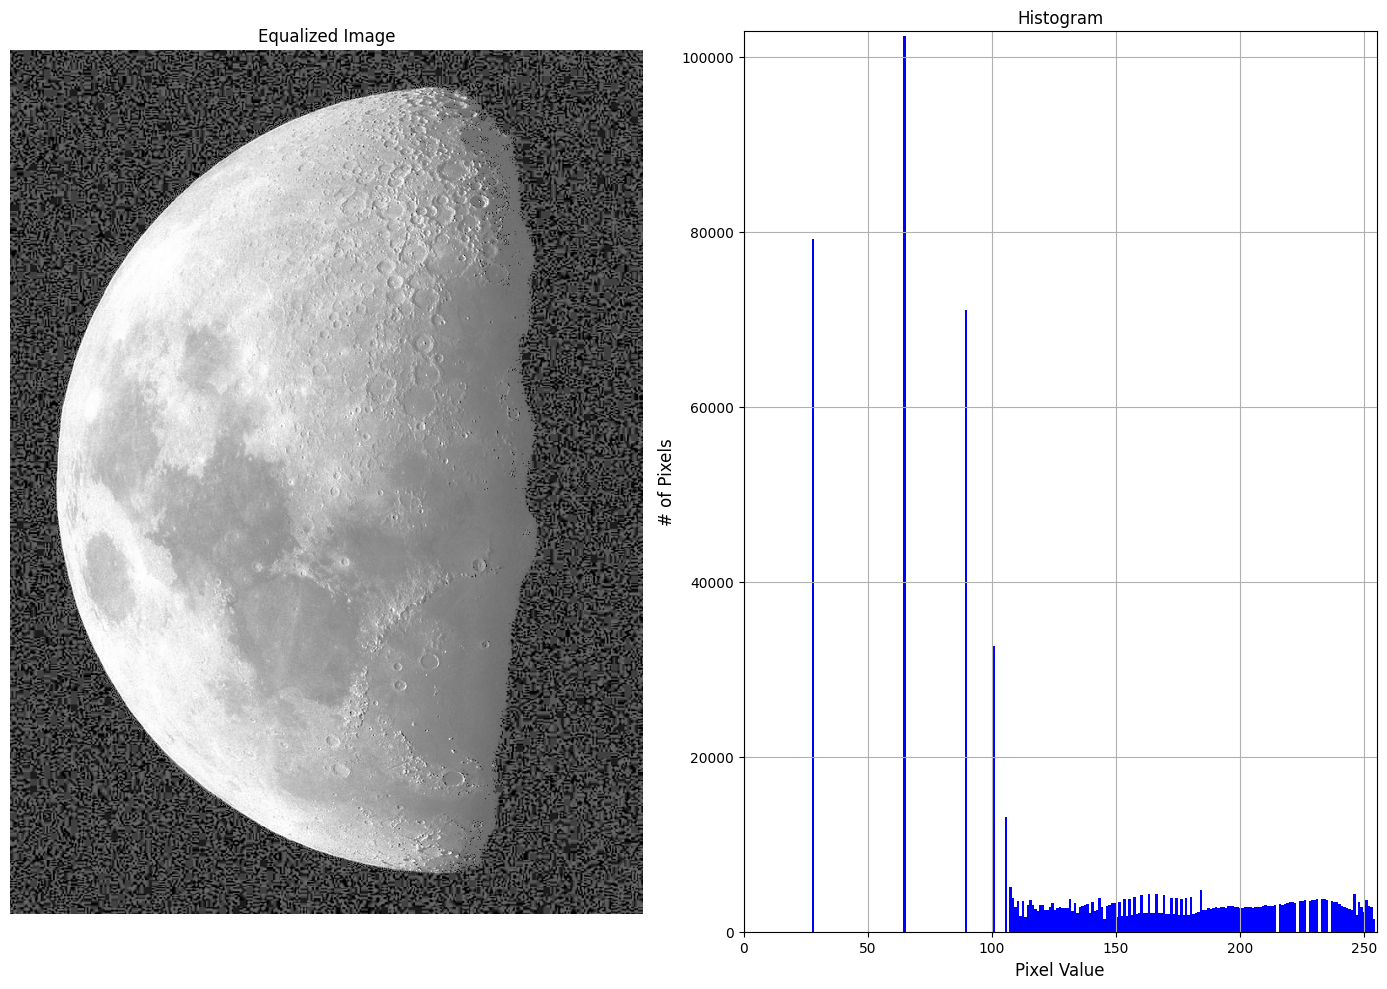

In [7]:
# Ex4_2: Histogram Equalization

eq_Img = cv2.equalizeHist(Img)
count_eq, bins_eq = np.histogram(eq_Img.flatten(), bins=256, range=(0, 255))

# Display_results
plt.figure(figsize=(14, 10))

plt.subplot(1, 2, 1), plt.imshow(eq_Img, cmap='gray')
plt.title('Equalized Image', fontsize=FS)
plt.axis('off')

plt.subplot(1, 2, 2), plt.bar(bins_eq[:-1], count_eq, width=1.0, color='blue')
plt.xlim([0, 255]), plt.ylim([0, count_eq.max()+500]), plt.grid(True)
plt.title('Histogram', fontsize=FS)
plt.xlabel('Pixel Value', fontsize=FS)
plt.ylabel('# of Pixels', fontsize=FS)

plt.tight_layout()
plt.savefig(PATH + 'Ex4_2.jpg', dpi=400)
plt.show()

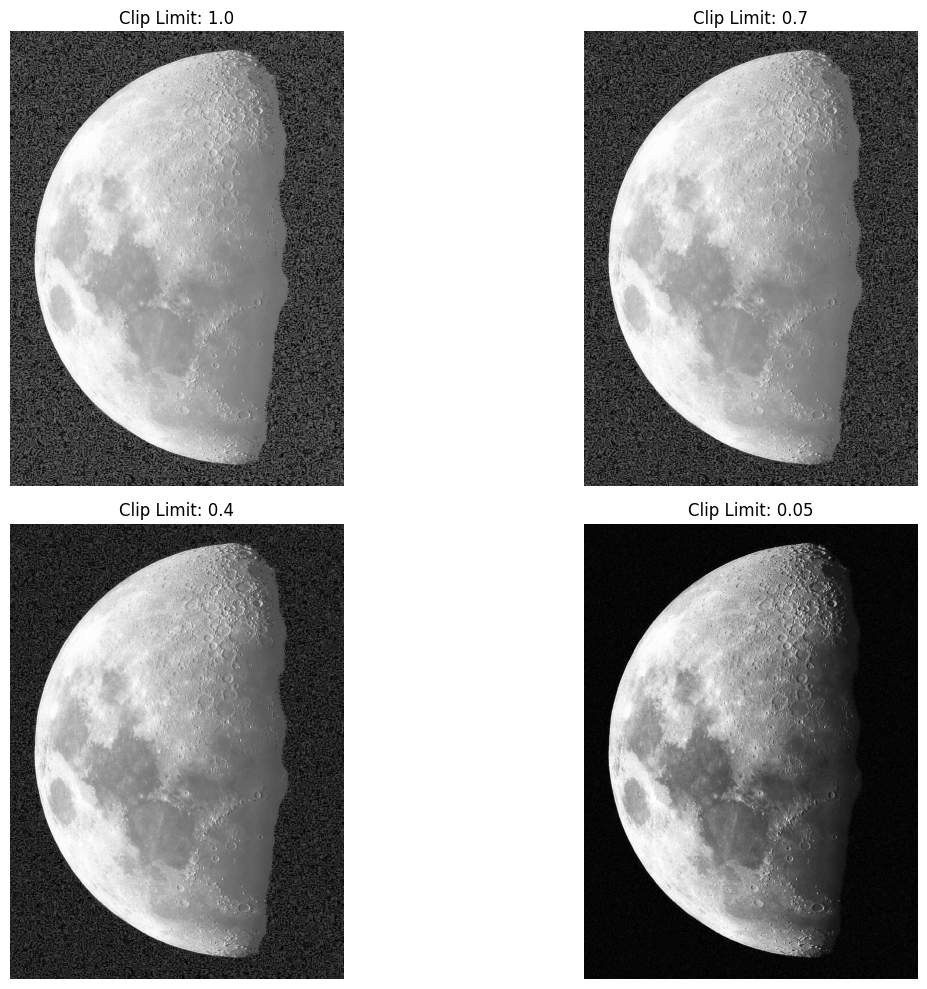

In [8]:
# Ex4_3: Contrast Limited Adaptive Histogram Equalization (CLAHE)
Img = cv2.imread(PATH + 'moon.jpg', cv2.IMREAD_GRAYSCALE)

count, bins = np.histogram(Img.flatten(), bins=256, range=(0, 255))
maxCount = count.max() #max number of pixels for a gray level

# Use CLAHE with different ratios
clip_limits = [1.0, 0.7, 0.4, 0.05]
limitedEq_Img = []
LUT = np.zeros((len(clip_limits), 256), dtype=np.uint8)

for i, c1 in enumerate(clip_limits):
    # Clipped histogram
    clip_value = c1 * maxCount
    clippedCount = np.minimum(count, clip_value)

    # Create a one-dimensional "virtual image" from clipped histogram
    clipped_Img = []
    for level in range(256):
      clipped_Img.extend([level] * int(clippedCount[level]))
    clipped_Img = np.array(clipped_Img, dtype=np.uint8)

    # Get mapping function
    eq_Img, T = cv2.equalizeHist(clipped_Img.reshape(1, -1)), None

    # Use LUT to perform histogram equalization
    hist_eq = cv2.equalizeHist(clipped_Img.reshape(1, -1))
    lut_vals = np.interp(np.arange(256), np.arange(256), np.cumsum(np.bincount(clipped_Img, minlength=256)) / clipped_Img.size)
    LUT[i, :] = np.clip(lut_vals * 255, 0, 255).astype(np.uint8)

    #apply LUT into the original image
    limitedEq_Img.append(cv2.LUT(Img, LUT[i, :]))

# Display_results
plt.figure(figsize=(14, 10))

for i, img in enumerate(limitedEq_Img):
    plt.subplot(2, 2, i+1), plt.imshow(img, cmap='gray')
    plt.title(f'Clip Limit: {clip_limits[i]}', fontsize=FS)
    plt.axis('off')
plt.tight_layout()
plt.savefig(PATH + 'Ex4_3.jpg', dpi=400)
plt.show()

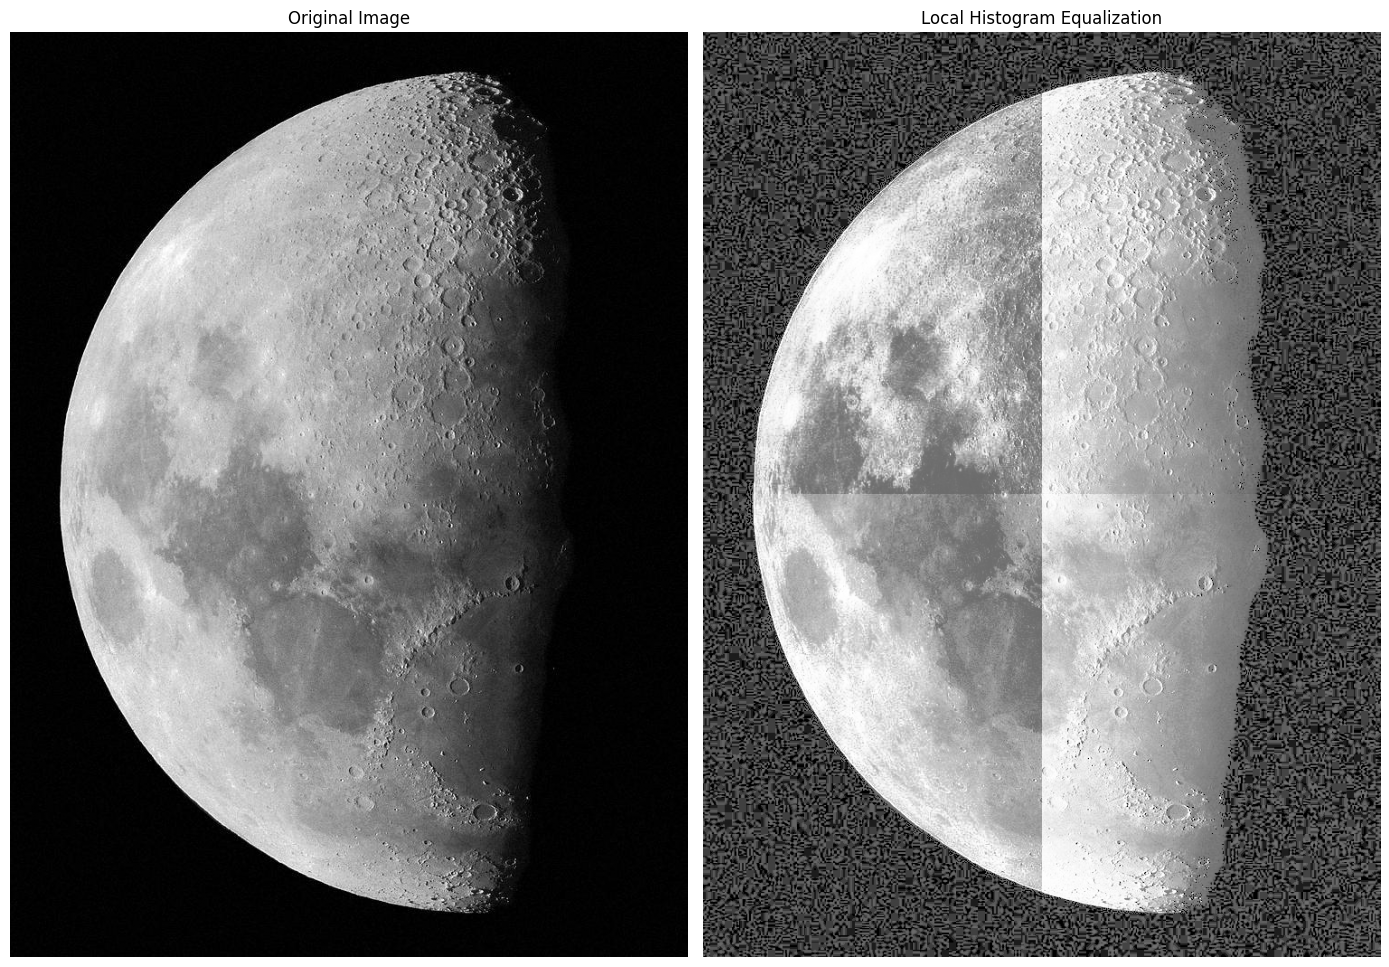

In [9]:
#Ex4_4: Local Histogram Equalization
Img = cv2.imread(PATH + 'moon.jpg', cv2.IMREAD_GRAYSCALE)

# Global histogram equalization
eq_Img = cv2.equalizeHist(Img)

# Local histogram equalization
h, w = Img.shape
block_size = (h // 2, w // 2)
lc_Img = np.zeros_like(Img)
for y in range(0, h, block_size[0]):
    for x in range(0, w, block_size[1]):
      y_end = min(y + block_size[0], h)
      x_end = min(x + block_size[1], w)
      block = Img[y:y_end, x:x_end]
      lc_Img[y:y_end, x:x_end] = cv2.equalizeHist(block)

# Displat results
plt.figure(figsize=(14, 10))

plt.subplot(1, 2, 1), plt.imshow(Img, cmap='gray')
plt.title('Original Image', fontsize=FS)
plt.axis('off')

plt.subplot(1, 2, 2), plt.imshow(lc_Img, cmap='gray')
plt.title('Local Histogram Equalization', fontsize=FS)
plt.axis('off')

plt.tight_layout()
plt.savefig(PATH + 'Ex4_4.jpg', dpi=400)
plt.show()